# XOR and NXOR Gate

## Import and Formatting

The goal of this section is to import all the necessary files and libraries required for the subsequent data analysis.  
It also includes setting up the formatting parameters for the plots and visualizations.

### Import

In [1]:
# ----  Standard import
import matplotlib.pyplot as plt
import numpy as np
import itertools

# ----- Spice impor t
from PySpice.Spice.Netlist import Circuit, SubCircuit
from PySpice.Unit import *

### Formatting

Adjusting Plotly chart settings for clarity and consistency.

In [2]:
# ----  Formatting charts
%matplotlib inline
from IPython.core.pylabtools import figsize
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.edgecolor']  = "#bcbcbc"
mpl.rcParams['patch.linewidth'] = 0.5
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['axes.facecolor']  = "#eeeeee"
mpl.rcParams['axes.labelsize']  = "large"
mpl.rcParams['axes.grid']       = True
mpl.rcParams['grid.linestyle']  = "--"
mpl.rcParams['patch.edgecolor'] = "#eeeeee"
mpl.rcParams['axes.titlesize']  = "x-large"

## Goal

The objective of this section is to understand the operation of the *XOR* logic gate as well as its inverse, the *NXOR* gate.

This study will first rely on the analysis of the **truth table** of these logic gates. We will then examine how these gates can be **implemented electronically**, particularly using transistors, in order to establish a clear connection between Boolean logic and its hardware realization.

## Electrical Symbol

In this book, the only standard used is the **European standard**.

The symbol is shown in [](#symbol_and). It is very simple: a rectangle containing an symbol (=1). The gate has two logical inputs (A and B) and one output (Y).

```{figure} ./images/symbol_xor.svg
:name: symbol_xor
:align: center
:width: 400px

Symbol for an XOR logic gate
```

## Truth Table

The truth table is given below:

```{table} Truth table of a XOR gate
:name: Table_de_verite_d_une_porte_XOR
:align: center

| A | B | Y |
| - | - | - |
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |
```

The truth table of an AND gate is very simple ([](#Table_de_verite_d_une_porte_XOR)).To obtain an output value equal to `1`, at least one of the two inputs—or both inputs—must be equal to `1`. Overwise, the output value is `0`. 

Conversely, for a `NOR` gate ([](#Table_de_verite_d_une_porte_NXOR)), both inputs *A* and *B* must be equal to `0` for the output to be `1`. Otherwise, the output value is `0`.

```{table} Truth table of a NXOR gate
:name: Table_de_verite_d_une_porte_NXOR
:align: center

| A | B | Y |
| - | - | - |
| 0 | 0 | 1 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | 1 |
```

## Building an XOR Gate

The XOR gate is **not a fundamental logic gate**.  
The three fundamental logic gates are:

* NAND  
* NOR  
* NOT  

However, it is possible to **build XOR and XNOR gates using these fundamental gates**.

### Mathematical Representation

#### XOR

For an XOR gate:

$$
Y = A \oplus B
$$

$$
Y = (A + B) \cdot \overline{(A \cdot B)}
$$

#### XNOR (NXOR)

The same idea can be used to build an XNOR gate:

$$
Y = \overline{A \oplus B}
$$

$$
Y = \overline{(A + B) \cdot \overline{(A \cdot B)}}
$$

Using De Morgan’s laws:

$$
Y = \overline{A + B} + \overline{\overline{(A \cdot B)}}
$$

$$
Y = \overline{A + B} + (A \cdot B)
$$

Once these equations are established, it is possible to design the corresponding **electronic circuit**.

## Electronic Circuits

In the first part, the goal is to design the XOR and XNOR gates **using only logic gates**.  
After that, thanks to logic circuits, it is possible to **implement these gates using CMOS technology**.


### Logic Circuits

#### XOR

There are several ways to build an XOR gate. One possible implementation is shown in  [](#circuit_electronique_logical_XOR).

To better understand this circuit, the **truth table** and the **logic demonstration** are shown in  [](#Table_de_verite_d_une_porte_XOR_demonstration) and  [](#circuit_electronique_logical_XOR_demonstration).

This implementation uses **three logic gates**:
- one NAND gate  
- one AND gate  
- one OR gate  

```{figure} ./images/logical_XOR.svg
:name: circuit_electronique_logical_XOR
:align: center
:width: 400px

XOR gate built with logic gates
````

```{table} Truth table of a XOR gate
:name: Table_de_verite_d_une_porte_XOR_demonstration
:align: center

| A | B | OR | NAND | AND |
| - | - | -- | ---- | --- |
| 0 | 0 |  0 |  1   |  0  |
| 0 | 1 |  1 |  1   |  1  |
| 1 | 0 |  1 |  1   |  1  |
| 1 | 1 |  1 |  0   |  0  |
```

```{figure} ./images/logical_XOR_demonstration.svg
:name: circuit_electronique_logical_XOR_demonstration
:align: center
:width: 400px

Logic demonstration of the XOR gate
```


#### XNOR

The same reasoning applies to the XNOR gate. The corresponding logic circuit is shown in [](#circuit_electronique_logical_NXOR).

```{figure} ./images/logical_NXOR.svg
:name: circuit_electronique_logical_NXOR
:align: center
:width: 400px

XNOR gate built with logic gates
```

### CMOS Circuits

#### XOR

Using the logic-gate implementation shown in [](#circuit_electronique_logical_XOR), we can estimate the maximum number of transistors:

* NAND gate: 4 transistors
* AND gate: 6 transistors
* OR gate: 6 transistors

This results in a maximum of **16 transistors**.

However, in the CMOS implementation shown in [](#circuit_electronique_CMOS_XOR), only **12 transistors** are required.

This circuit is relatively easy to understand:
* **M1 and M2** form an inverter
* **M3 and M4** form another inverter
* **Transistors M5 to M12** implement all cases of the XOR truth table:
  * **M5 and M6** conduct when `A = 0` and `B = 1` (A and B are different)
  * **M7 and M8** conduct when `A = 1` and `B = 0` (A and B are different)
  * **M9 and M10** conduct when `A = 1` and `B = 1` (A and B are equal)
  * **M11 and M12** conduct when `A = 0` and `B = 0` (A and B are equal)

```{figure} ./images/CMOS_XOR.svg
:name: circuit_electronique_CMOS_XOR
:align: center
:width: 400px

XOR gate implemented with CMOS
```


#### XNOR

The same reasoning applies to the XNOR gate. The CMOS implementation is shown in [](#circuit_electronique_CMOS_NXOR).

```{figure} ./images/CMOS_NXOR.svg
:name: circuit_electronique_CMOS_NXOR
:align: center
:width: 400px

XNOR gate implemented with CMOS
```

## Spice

In this part, the goal is create the circuit of XOR and XNOR with Spice


### Spice XOR

The circuit is show in [](#circuit_electronique_CMOS_XOR_spice).


```{figure} ./images/CMOS_XOR_spice.svg
:name: circuit_electronique_CMOS_XOR_spice
:align: center
:width: 500px

XOR gate built with CMOS (Spice)
````

#### Simulation

In [3]:
# ============================================================
# CMOS NOR Gate 
# Technology: PTM 65 nm
# ============================================================

# Create the circuit object
circuit = Circuit('CMOS XOR')

# ============================================================
# Model Libraries
# Include NMOS and PMOS transistor models
# ============================================================

circuit.include('lib/ptm_65nm_nmos_bulk.mod')
circuit.include('lib/ptm_65nm_pmos_bulk.mod')

# ============================================================
# Power Supply Definition
# ============================================================

# Supply voltage
VDD = 1.2

# DC power supply (VDD)
circuit.V('dd', 'vdd', circuit.gnd, VDD @ u_V)

# ============================================================
# Input Signal Definitions
# Two pulse voltage sources are used to test all logic states
# ============================================================

# Input A: faster pulse
circuit.PulseVoltageSource(
    'A',
    'va',
    circuit.gnd,
    0 @ u_V, VDD @ u_V,
    pulse_width=5 @ u_ns,
    period=10 @ u_ns
)

# Input B: slower pulse
circuit.PulseVoltageSource(
    'B',
    'vb',
    circuit.gnd,
    0 @ u_V, VDD @ u_V,
    pulse_width=10 @ u_ns,
    period=20 @ u_ns
)

# ============================================================
# CMOS Logic Core
# XOR gate implementation
# ============================================================

# ----------------------------
# CMOS Inverter
# ----------------------------

# ---- va to vainv
circuit.MOSFET(
    1,
    'vainv', 'va', 'vdd', 'vdd',
    model='ptm65nm_pmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

circuit.MOSFET(
    2,
    'vainv', 'va', circuit.gnd, circuit.gnd,
    model='ptm65nm_nmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

# ---- vb to vbinv
circuit.MOSFET(
    3,
    'vbinv', 'vb', 'vdd', 'vdd',
    model='ptm65nm_pmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

circuit.MOSFET(
    4,
    'vbinv', 'vb', circuit.gnd, circuit.gnd,
    model='ptm65nm_nmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
);

# ----------------------------
# PMOS Pull-Up Network (PUN)
# PMOS transistors are connected in parallel
# ----------------------------

# --- Part right
circuit.MOSFET(
    5,
    'm5m6', 'va', 'vdd', 'vdd',
    model='ptm65nm_pmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

circuit.MOSFET(
    6,
    'vout', 'vbinv', 'm5m6', 'vdd',
    model='ptm65nm_pmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

# --- Part left
circuit.MOSFET(
    7,
    'm7m8', 'vainv', 'vdd', 'vdd',
    model='ptm65nm_pmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

circuit.MOSFET(
    8,
    'vout', 'vb', 'm7m8', 'vdd',
    model='ptm65nm_pmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

# ----------------------------
# NMOS Pull-Down Network (PDN)
# NMOS transistors are connected in series
# ----------------------------

# --- Part right
circuit.MOSFET(
    9,
    'vout', 'va', 'm9m10', circuit.gnd,
    model='ptm65nm_nmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

circuit.MOSFET(
    10,
    'm9m10', 'vb', circuit.gnd, circuit.gnd,
    model='ptm65nm_nmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

# --- Part left
circuit.MOSFET(
    11,
    'vout', 'vainv', 'm11m12', circuit.gnd,
    model='ptm65nm_nmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

circuit.MOSFET(
    12,
    'm11m12', 'vbinv', circuit.gnd, circuit.gnd,
    model='ptm65nm_nmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
);

In [4]:
# ============================================================
# Simulation Setup
# Transient analysis of the CMOS logic gate
# ============================================================

# Create the simulator instance
# Temperature parameters are set to nominal operating conditions
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# ============================================================
# Transient Analysis
# ============================================================

# Perform a transient simulation to observe the dynamic behavior
# of the inputs (A, B) and the output (Vout)
analysis = simulator.transient(
    step_time=0.1 @ u_ns,
    end_time=20 @ u_ns
)

#### Chronogram XOR Gate

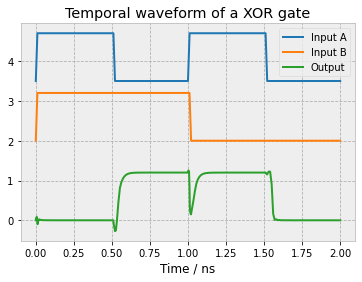

In [5]:
# Plot the transient waveforms
plt.figure()
plt.title("Temporal waveform of a XOR gate")

# Input signals (shifted vertically for clarity)
plt.plot(analysis.time * 1e8, np.array(analysis["va"]) + 3.5, label="Input A")
plt.plot(analysis.time * 1e8, np.array(analysis["vb"]) + 2.0, label="Input B")

# Output signal
plt.plot(analysis.time * 1e8, analysis["vout"], label="Output")

# Axis labels and legend
plt.xlabel("Time / ns")
plt.legend()
plt.show()

It is possible to observe several things in this timing diagram. First, the truth table of a XOR gate can be clearly identified: both inputs *A* and *B* must be different for the output to be `1`. In all other cases, the output remains at `0`.

Another important point is that during transitions of inputs *A* and *B*, fluctuations can be observed at the output. These effects are due to switching phenomena in the transistors. In the next part of the report, the objective will be to correct or mitigate these fluctuations.

Before addressing this issue, the next goal is to obtain a clearer representation of the truth table. For now, there are only two inputs, but in cases with more inputs, it becomes much more difficult to visualize all possible responses using a simple timing diagram.

#### XOR Gate Logic Visualization

In [6]:
def logic(level):
    return VDD@ u_V if level else 0 @ u_V

In [7]:
class Xor12T(SubCircuit):
    """
    CMOS XOR gate – fully complementary static implementation (12T)

    This XOR gate is implemented using:
    - Two CMOS inverters to generate A̅ and B̅
    - A complementary PMOS Pull-Up Network (PUN)
    - A complementary NMOS Pull-Down Network (PDN)

    Logic function:
        Y = A ⊙ B = (A · B) + (A̅ · B̅)

    Characteristics:
        ✔ Full voltage swing
        ✔ No static power consumption
        ✔ Good noise margins
        ✔ Robust for cascading

    External nodes:
        A   : Input A
        B   : Input B
        Y   : XNOR output
        VDD : Power supply
    """

    __nodes__ = ('A', 'B', 'Y', 'VDD')

    def __init__(self, name):
        """
        Initialize the 12-transistor CMOS XNOR gate.

        Parameters
        ----------
        name : str
            Subcircuit instance name
        """
        super().__init__(name, *self.__nodes__)

        # ============================================================
        # Internal nodes
        # ============================================================

        vainv  = 'vainv'     # Inverted input A (A̅)
        vbinv  = 'vbinv'     # Inverted input B (B̅)

        m5m6   = 'm5m6'      # Internal PMOS node (right branch)
        m7m8   = 'm7m8'      # Internal PMOS node (left branch)

        m9m10  = 'm9m10'     # Internal NMOS node (right branch)
        m11m12 = 'm11m12'    # Internal NMOS node (left branch)

        # ============================================================
        # Input inverters (A → A̅, B → B̅)
        # ============================================================

        # ---- Inverter for input A
        self.MOSFET(
            'P_AINV',
            vainv, 'A', 'VDD', 'VDD',
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.5  @ u_um
        )

        self.MOSFET(
            'N_AINV',
            vainv, 'A', self.gnd, self.gnd,
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.5  @ u_um
        )

        # ---- Inverter for input B
        self.MOSFET(
            'P_BINV',
            vbinv, 'B', 'VDD', 'VDD',
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.5  @ u_um
        )

        self.MOSFET(
            'N_BINV',
            vbinv, 'B', self.gnd, self.gnd,
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.5  @ u_um
        )

        # ============================================================
        # PMOS Pull-Up Network (PUN)
        # Implements: (A · B) + (A̅ · B̅)
        # ============================================================

        # --- Right branch: A · B
        self.MOSFET(
            'P5',
            m5m6, 'A', 'VDD', 'VDD',
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.5  @ u_um
        )

        self.MOSFET(
            'P6',
            'Y', vbinv, m5m6, 'VDD',
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.5  @ u_um
        )

        # --- Left branch: A̅ · B̅
        self.MOSFET(
            'P7',
            m7m8, vainv, 'VDD', 'VDD',
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.5  @ u_um
        )

        self.MOSFET(
            'P8',
            'Y', 'B', m7m8, 'VDD',
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.5  @ u_um
        )

        # ============================================================
        # NMOS Pull-Down Network (PDN)
        # Implements: (A · B̅) + (A̅ · B)
        # ============================================================

        # --- Right branch: A · B
        self.MOSFET(
            'N9',
            'Y', 'A', m9m10, self.gnd,
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.5  @ u_um
        )

        self.MOSFET(
            'N10',
            m9m10, 'B', self.gnd, self.gnd,
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.5  @ u_um
        )

        # --- Left branch: A̅ · B̅
        self.MOSFET(
            'N11',
            'Y', vainv, m11m12, self.gnd,
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.5  @ u_um
        )

        self.MOSFET(
            'N12',
            m11m12, vbinv, self.gnd, self.gnd,
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.5  @ u_um
        )

In [8]:
# Store simulation results
results = []

# Iterate over all input combinations (truth table)
for A, B in itertools.product([0, 1], repeat=2):

    # Create a new circuit for each input combination
    circuit = Circuit(f'CMOS AND A={A} B={B}')

    # Include transistor models
    circuit.include('lib/ptm_65nm_nmos_bulk.mod')
    circuit.include('lib/ptm_65nm_pmos_bulk.mod')
    
    # Power supply
    circuit.V('dd', 'vdd', circuit.gnd, VDD)

    # Logic inputs (DC values)
    circuit.V('A', 'va', circuit.gnd, logic(A))
    circuit.V('B', 'vb', circuit.gnd, logic(B))

    # ============================================================
    # CMOS Logic Core
    # XOR gate implementation
    # ============================================================
    
    # ----------------------------
    # CMOS Inverter
    # ----------------------------
    
    circuit.subcircuit(Xor12T('XOR'))
    circuit.X('X1', 'XOR', 'va', 'vb', 'vout', 'vdd')

    # ========================================================
    # DC operating point analysis
    # ========================================================

    simulator = circuit.simulator()
    analysis = simulator.operating_point()

    # Store output voltage
    Vout = float(analysis['vout'][0])
    results.append((A, B, Vout))

In [9]:
# ============================================================
# Truth Table Verification
# ============================================================

print("Truth Table Verification")
print("------------------------")
print(" A  B   Vout (V)   Y")

# Logic threshold: midpoint of VDD
Vth = float(VDD) / 2

for A, B, Vout in results:
    # Convert analog output voltage to logical value
    Y = 1 if Vout > Vth else 0
    print(f" {A}  {B}   {Vout:.3f}      {Y}")

Truth Table Verification
------------------------
 A  B   Vout (V)   Y
 0  0   0.001      0
 0  1   1.200      1
 1  0   1.200      1
 1  1   0.001      0


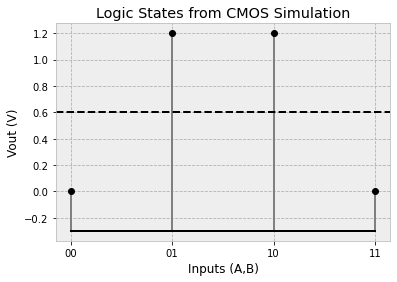

In [10]:
# ============================================================
# Plot CMOS simulation output for all input combinations
# ============================================================

# Labels for each input combination (A,B)
labels = [f"{A}{B}" for A, B, _ in results]

# Corresponding output voltages
Vouts = [Vout for _, _, Vout in results]

# Stem plot for visualizing discrete logic states
plt.stem(
    labels,
    Vouts,
    markerfmt="black",
    linefmt="grey",
    basefmt='black',
    bottom=-0.3  # shift baseline for clarity
)

# Logic threshold line
plt.axhline(Vth, linestyle='--', color="black", label="Logic Threshold")

# Axis labels and title
plt.ylabel("Vout (V)")
plt.xlabel("Inputs (A,B)")
plt.title("Logic States from CMOS Simulation")
plt.show()

The truth table of a `XOR` gate can be clearly observed from the simulation results.

This type of visualization makes it much easier to see all possible outcomes of a logic function.

### Spice XNOR

The circuit is show in [](#circuit_electronique_CMOS_NXOR_spice).


```{figure} ./images/CMOS_NXOR_spice.svg
:name: circuit_electronique_CMOS_NXOR_spice
:align: center
:width: 500px

NXOR gate built with CMOS (Spice)
````

#### Simulation

In [11]:
# ============================================================
# CMOS NOR Gate 
# Technology: PTM 65 nm
# ============================================================

# Create the circuit object
circuit = Circuit('CMOS XOR')

# ============================================================
# Model Libraries
# Include NMOS and PMOS transistor models
# ============================================================

circuit.include('lib/ptm_65nm_nmos_bulk.mod')
circuit.include('lib/ptm_65nm_pmos_bulk.mod')

# ============================================================
# Power Supply Definition
# ============================================================

# Supply voltage
VDD = 1.2

# DC power supply (VDD)
circuit.V('dd', 'vdd', circuit.gnd, VDD @ u_V)

# ============================================================
# Input Signal Definitions
# Two pulse voltage sources are used to test all logic states
# ============================================================

# Input A: faster pulse
circuit.PulseVoltageSource(
    'A',
    'va',
    circuit.gnd,
    0 @ u_V, VDD @ u_V,
    pulse_width=5 @ u_ns,
    period=10 @ u_ns
)

# Input B: slower pulse
circuit.PulseVoltageSource(
    'B',
    'vb',
    circuit.gnd,
    0 @ u_V, VDD @ u_V,
    pulse_width=10 @ u_ns,
    period=20 @ u_ns
)

# ============================================================
# CMOS Logic Core
# XOR gate implementation
# ============================================================

# ----------------------------
# CMOS Inverter
# ----------------------------

# ---- va to vainv
circuit.MOSFET(
    1,
    'vainv', 'va', 'vdd', 'vdd',
    model='ptm65nm_pmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

circuit.MOSFET(
    2,
    'vainv', 'va', circuit.gnd, circuit.gnd,
    model='ptm65nm_nmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

# ---- vb to vbinv
circuit.MOSFET(
    3,
    'vbinv', 'vb', 'vdd', 'vdd',
    model='ptm65nm_pmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

circuit.MOSFET(
    4,
    'vbinv', 'vb', circuit.gnd, circuit.gnd,
    model='ptm65nm_nmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
);

# ----------------------------
# PMOS Pull-Up Network (PUN)
# PMOS transistors are connected in parallel
# ----------------------------

# --- Part right
circuit.MOSFET(
    5,
    'm5m6', 'va', 'vdd', 'vdd',
    model='ptm65nm_pmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

circuit.MOSFET(
    6,
    'vout', 'vb', 'm5m6', 'vdd',
    model='ptm65nm_pmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

# --- Part left
circuit.MOSFET(
    7,
    'm7m8', 'vainv', 'vdd', 'vdd',
    model='ptm65nm_pmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

circuit.MOSFET(
    8,
    'vout', 'vbinv', 'm7m8', 'vdd',
    model='ptm65nm_pmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

# ----------------------------
# NMOS Pull-Down Network (PDN)
# NMOS transistors are connected in series
# ----------------------------

# --- Part right
circuit.MOSFET(
    9,
    'vout', 'va', 'm9m10', circuit.gnd,
    model='ptm65nm_nmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

circuit.MOSFET(
    10,
    'm9m10', 'vbinv', circuit.gnd, circuit.gnd,
    model='ptm65nm_nmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

# --- Part left
circuit.MOSFET(
    11,
    'vout', 'vainv', 'm11m12', circuit.gnd,
    model='ptm65nm_nmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
)

circuit.MOSFET(
    12,
    'm11m12', 'vb', circuit.gnd, circuit.gnd,
    model='ptm65nm_nmos',
    l=0.35 @ u_um,
    w=0.5 @ u_um
);

In [12]:
# ============================================================
# Simulation Setup
# Transient analysis of the CMOS logic gate
# ============================================================

# Create the simulator instance
# Temperature parameters are set to nominal operating conditions
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# ============================================================
# Transient Analysis
# ============================================================

# Perform a transient simulation to observe the dynamic behavior
# of the inputs (A, B) and the output (Vout)
analysis = simulator.transient(
    step_time=0.1 @ u_ns,
    end_time=20 @ u_ns
)

#### Chronogram XOR Gate

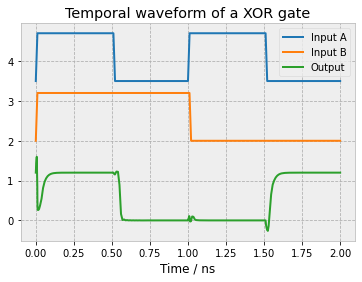

In [13]:
# Plot the transient waveforms
plt.figure()
plt.title("Temporal waveform of a XOR gate")

# Input signals (shifted vertically for clarity)
plt.plot(analysis.time * 1e8, np.array(analysis["va"]) + 3.5, label="Input A")
plt.plot(analysis.time * 1e8, np.array(analysis["vb"]) + 2.0, label="Input B")

# Output signal
plt.plot(analysis.time * 1e8, analysis["vout"], label="Output")

# Axis labels and legend
plt.xlabel("Time / ns")
plt.legend()
plt.show()

It is possible to observe several things in this timing diagram. First, the truth table of a NXOR gate can be clearly identified: both inputs *A* and *B* must be same value for the output to be `1`. In all other cases, the output remains at `0`.

Another important point is that during transitions of inputs *A* and *B*, fluctuations can be observed at the output. These effects are due to switching phenomena in the transistors. In the next part of the report, the objective will be to correct or mitigate these fluctuations.

Before addressing this issue, the next goal is to obtain a clearer representation of the truth table. For now, there are only two inputs, but in cases with more inputs, it becomes much more difficult to visualize all possible responses using a simple timing diagram.

#### NXOR Gate Logic Visualization

In [14]:
def logic(level):
    return VDD@ u_V if level else 0 @ u_V

In [15]:
# Store simulation results
results = []

# Iterate over all input combinations (truth table)
for A, B in itertools.product([0, 1], repeat=2):

    # Create a new circuit for each input combination
    circuit = Circuit(f'CMOS AND A={A} B={B}')

    # Include transistor models
    circuit.include('lib/ptm_65nm_nmos_bulk.mod')
    circuit.include('lib/ptm_65nm_pmos_bulk.mod')
    
    # Power supply
    circuit.V('dd', 'vdd', circuit.gnd, VDD)

    # Logic inputs (DC values)
    circuit.V('A', 'va', circuit.gnd, logic(A))
    circuit.V('B', 'vb', circuit.gnd, logic(B))

    # ============================================================
    # CMOS Logic Core
    # XOR gate implementation
    # ============================================================
    
    # ----------------------------
    # CMOS Inverter
    # ----------------------------
    
    # ---- va to vainv
    circuit.MOSFET(
        1,
        'vainv', 'va', 'vdd', 'vdd',
        model='ptm65nm_pmos',
        l=0.35 @ u_um,
        w=0.5 @ u_um
    )
    
    circuit.MOSFET(
        2,
        'vainv', 'va', circuit.gnd, circuit.gnd,
        model='ptm65nm_nmos',
        l=0.35 @ u_um,
        w=0.5 @ u_um
    )
    
    # ---- vb to vbinv
    circuit.MOSFET(
        3,
        'vbinv', 'vb', 'vdd', 'vdd',
        model='ptm65nm_pmos',
        l=0.35 @ u_um,
        w=0.5 @ u_um
    )
    
    circuit.MOSFET(
        4,
        'vbinv', 'vb', circuit.gnd, circuit.gnd,
        model='ptm65nm_nmos',
        l=0.35 @ u_um,
        w=0.5 @ u_um
    )
    
    # ----------------------------
    # PMOS Pull-Up Network (PUN)
    # PMOS transistors are connected in parallel
    # ----------------------------
    
    # --- Part right
    circuit.MOSFET(
        5,
        'm5m6', 'va', 'vdd', 'vdd',
        model='ptm65nm_pmos',
        l=0.35 @ u_um,
        w=0.5 @ u_um
    )
    
    circuit.MOSFET(
        6,
        'vout', 'vb', 'm5m6', 'vdd',
        model='ptm65nm_pmos',
        l=0.35 @ u_um,
        w=0.5 @ u_um
    )
    
    # --- Part left
    circuit.MOSFET(
        7,
        'm7m8', 'vainv', 'vdd', 'vdd',
        model='ptm65nm_pmos',
        l=0.35 @ u_um,
        w=0.5 @ u_um
    )
    
    circuit.MOSFET(
        8,
        'vout', 'vbinv', 'm7m8', 'vdd',
        model='ptm65nm_pmos',
        l=0.35 @ u_um,
        w=0.5 @ u_um
    )
    
    # ----------------------------
    # NMOS Pull-Down Network (PDN)
    # NMOS transistors are connected in series
    # ----------------------------
    
    # --- Part right
    circuit.MOSFET(
        9,
        'vout', 'va', 'm9m10', circuit.gnd,
        model='ptm65nm_nmos',
        l=0.35 @ u_um,
        w=0.5 @ u_um
    )
    
    circuit.MOSFET(
        10,
        'm9m10', 'vbinv', circuit.gnd, circuit.gnd,
        model='ptm65nm_nmos',
        l=0.35 @ u_um,
        w=0.5 @ u_um
    )
    
    # --- Part left
    circuit.MOSFET(
        11,
        'vout', 'vainv', 'm11m12', circuit.gnd,
        model='ptm65nm_nmos',
        l=0.35 @ u_um,
        w=0.5 @ u_um
    )
    
    circuit.MOSFET(
        12,
        'm11m12', 'vb', circuit.gnd, circuit.gnd,
        model='ptm65nm_nmos',
        l=0.35 @ u_um,
        w=0.5 @ u_um
    )

    # ========================================================
    # DC operating point analysis
    # ========================================================

    simulator = circuit.simulator()
    analysis = simulator.operating_point()

    # Store output voltage
    Vout = float(analysis['vout'][0])
    results.append((A, B, Vout))

In [16]:
# ============================================================
# Truth Table Verification
# ============================================================

print("Truth Table Verification")
print("------------------------")
print(" A  B   Vout (V)   Y")

# Logic threshold: midpoint of VDD
Vth = float(VDD) / 2

for A, B, Vout in results:
    # Convert analog output voltage to logical value
    Y = 1 if Vout > Vth else 0
    print(f" {A}  {B}   {Vout:.3f}      {Y}")

Truth Table Verification
------------------------
 A  B   Vout (V)   Y
 0  0   1.200      1
 0  1   0.001      0
 1  0   0.001      0
 1  1   1.200      1


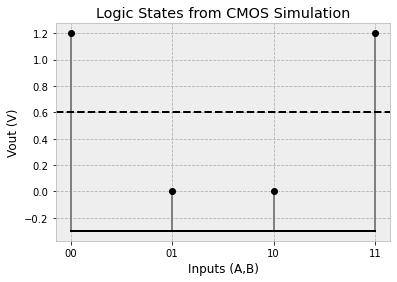

In [17]:
# ============================================================
# Plot CMOS simulation output for all input combinations
# ============================================================

# Labels for each input combination (A,B)
labels = [f"{A}{B}" for A, B, _ in results]

# Corresponding output voltages
Vouts = [Vout for _, _, Vout in results]

# Stem plot for visualizing discrete logic states
plt.stem(
    labels,
    Vouts,
    markerfmt="black",
    linefmt="grey",
    basefmt='black',
    bottom=-0.3  # shift baseline for clarity
)

# Logic threshold line
plt.axhline(Vth, linestyle='--', color="black", label="Logic Threshold")

# Axis labels and title
plt.ylabel("Vout (V)")
plt.xlabel("Inputs (A,B)")
plt.title("Logic States from CMOS Simulation")
plt.show()

The truth table of a `NXOR` gate can be clearly observed from the simulation results.

This type of visualization makes it much easier to see all possible outcomes of a logic function.

## Other Reduced Circuits

There are many possible ways to implement an XOR gate.
In the previous section, we studied a solution using 12 transistors, but it is also possible to design XOR gates using 10, 6, or even 4 transistors. These solutions are presented in {cite}`westeCMOSVLSIDesign2011`.

Each of these implementations has advantages and disadvantages.
For example:
* Fewer transistors usually mean smaller area and lower power consumption
* However, reduced-transistor designs may suffer from signal degradation, reduced noise margins, or limited voltage swing

In this section, the objective is to present and analyze examples of alternative XOR circuit implementations, highlighting their design trade-offs and practical limitations.

### 10 transistors

#### Explanation

On the [](#circuit_electronique_CMOS_XOR_reduct_10), therer are 10 transistors. For reducte the number of transistor, it is importante to use transmission gate design. After the understand the circuit, he most easyer to show [](#circuit_electronique_symbolique_XOR_reduct_10)

```{figure} ./images/CMOS_XOR_reduct_10.svg
:name: circuit_electronique_CMOS_XOR_reduct_10
:align: center
:width: 300px

XOR gate built with CMOS 10 Transistors
````

```{figure} ./images/symbolique_XOR_reduct_10.svg
:name: circuit_electronique_symbolique_XOR_reduct_10
:align: center
:width: 300px

XOR gate built with CMOS 10 Transistors (symbolique)
````

The [](#circuit_electronique_symbolique_XOR_reduct_10) is same to the [](#circuit_electronique_CMOS_XOR_reduct_10). If the input ``A`` is low level, so the level of the second stage is inverse of ``B``. If the value inverse of ``B`` is 0 so the differente level of ``A`` the output value is ``1`` but if the level of ``B`` is 1, the same level of ``A`` the output is 0. For simplify the understand we have the four case show in [](#circuit_electronique_symbolique_XOR_reduct_10_demonstration)

```{figure} ./images/symbolique_XOR_reduct_10_demonstration.svg
:name: circuit_electronique_symbolique_XOR_reduct_10_demonstration
:align: center
:width: 500px

XOR gate built with CMOS 10 Transistors (symbolique demonstration)
````

#### Spice

In this section the goal is juste build the subcircuit for next to compare all the model.

In [18]:
class Inversor(SubCircuit):
    """
    CMOS Inverter (NOT gate)

    External nodes:
        A   : Input
        Y   : Output
        VDD : Power supply
    """

    # Declare external terminals of the subcircuit
    __nodes__ = ('A', 'Y', 'VDD')

    def __init__(self, name):
        """
        Initialize a CMOS inverter subcircuit.

        Parameters
        ----------
        name : str
            Name of the subcircuit instance
        """
        # Initialize the SubCircuit
        super().__init__(name, *self.__nodes__)

        # ============================================================
        # PMOS transistor (pull-up network)
        # ============================================================
        # When A = 0 → PMOS turns ON → output Y goes HIGH
        # Source and bulk are connected to VDD
        self.MOSFET(
            'P1',            # Transistor name
            'Y',             # Drain
            'A',             # Gate
            'VDD',           # Source
            'VDD',           # Bulk
            model='ptm65nm_pmos',
            l=0.35 @ u_um,   # Channel length
            w=0.3 @ u_um,    # Channel width
        )

        # ============================================================
        # NMOS transistor (pull-down network)
        # ============================================================
        # When A = 1 → NMOS turns ON → output Y goes LOW
        # Source and bulk are connected to ground
        self.MOSFET(
            'N1',            # Transistor name
            'Y',             # Drain
            'A',             # Gate
            self.gnd,        # Source
            self.gnd,        # Bulk
            model='ptm65nm_nmos',
            l=0.35 @ u_um,   # Channel length
            w=0.3 @ u_um,    # Channel width
        )

In [19]:
class TransmissionGate(SubCircuit):
    """
    CMOS Transmission Gate

    External nodes:
        A   : Data input
        Y   : Data output
        Sn  : NMOS control signal (active HIGH)
        Sp  : PMOS control signal (active LOW)
        VDD : Power supply
    """

    # Order of nodes matters!
    __nodes__ = ('A', 'Y', 'Sn', 'Sp', 'VDD')

    def __init__(self, name):
        """
        Initialize a CMOS transmission gate.

        Parameters
        ----------
        name : str
            Subcircuit instance name
        """
        super().__init__(name, *self.__nodes__)

        # ============================================================
        # PMOS pass transistor
        # Conducts when Sp = 0
        # Passes strong '1'
        # ============================================================
        self.MOSFET(
            'P1',            # Transistor name
            'Y',             # Drain
            'Sp',            # Gate
            'A',             # Source
            'VDD',           # Bulk
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.3 @ u_um
        )

        # ============================================================
        # NMOS pass transistor
        # Conducts when Sn = 1
        # Passes strong '0'
        # ============================================================
        self.MOSFET(
            'N1',            # Transistor name
            'Y',             # Drain
            'Sn',            # Gate
            'A',             # Source
            self.gnd,        # Bulk
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.3 @ u_um
        )

In [20]:
class Xor10T(SubCircuit):
    """
    CMOS XOR gate (10-transistor implementation)
    Based on transmission gates + inverters

    External nodes:
        A   : Input A
        B   : Input B
        Y   : Output
        VDD : Power supply
    """

    __nodes__ = ('A', 'B', 'Y', 'VDD')

    def __init__(self, name):
        super().__init__(name, *self.__nodes__)

        # Internal nodes
        a_bar = 'a_bar'
        b_bar = 'b_bar'
        vinter = 'vinter'

        # Invert A and B
        self.X('IA', 'INV', 'A', a_bar, 'VDD')
        self.X('IB', 'INV', 'B', b_bar, 'VDD')

        # Transmission gate logic
        # If A=0 → pass B̅
        self.X('TG1', 'TRANS', b_bar, vinter, a_bar, 'A', 'VDD')

        # If A=1 → pass B
        self.X('TG2', 'TRANS', 'B', vinter, 'A', a_bar, 'VDD')

        # Final inverter
        self.X('IO', 'INV', vinter, 'Y', 'VDD')

### 6 transistors

#### Explanation

On the [](#circuit_electronique_symbolique_XOR_reduct_6), therer are 6 transistors. For reduct the number of transistor now, this circuit use just one transmission gate in the other circuit ([](#circuit_electronique_CMOS_XOR_reduct_10)) there are two transmission gate. The other modification big modification is the output. Now the output isn't rail-to-rail. So if the `A` or `B` output tension is not VDD the output is not perfect the good tension. This can create many problem if you are many stage. So, it is possible to add juste one stage with inversor gate and the circuit is rail-to-rail. The circuit symbolique is repreted in the [](#circuit_electronique_symbolique_XOR_reduct_6)

```{figure} ./images/CMOS_XOR_reduct_6.svg
:name: circuit_electronique_CMOS_XOR_reduct_6
:align: center
:width: 300px

XOR gate built with CMOS 6 Transistors
````

```{figure} ./images/symbolique_XOR_reduct_6.svg
:name: circuit_electronique_symbolique_XOR_reduct_6
:align: center
:width: 300px

XOR gate built with CMOS 6 Transistors (symbolique)
````



```{figure} ./images/symbolique_XOR_reduct_6_demonstration.svg
:name: circuit_electronique_symbolique_XOR_reduct_6_demonstration
:align: center
:width: 500px

XOR gate built with CMOS 6 Transistors (symbolique demonstration)
````

#### Spice

In this section the goal is juste build the subcircuit for next to compare all the model.

In [21]:
class Xor6T(SubCircuit):
    """
    CMOS XOR gate – 6-transistor implementation (pass-transistor logic)

    This XOR topology is based on the classical 6T structure described
    in CMOS VLSI Design. It relies on pass-transistor logic combined with
    a single inverter to generate A̅.

    ⚠ Important notes:
    - The output node is NOT level-restored.
    - Voltage degradation may occur (VDD - Vth).
    - This cell is typically used as an internal logic block and is
      usually followed by a restoring inverter.

    External nodes:
        A   : Input A
        B   : Input B
        Y   : XOR output (non-restored)
        VDD : Power supply
    """

    # Declaration of the external terminals of the subcircuit
    __nodes__ = ('A', 'B', 'Y', 'VDD')

    def __init__(self, name):
        """
        Initialize the 6T CMOS XOR gate.

        Parameters
        ----------
        name : str
            Instance name of the subcircuit
        """
        # Initialize the SubCircuit with its external nodes
        super().__init__(name, *self.__nodes__)

        # ============================================================
        # Internal nodes
        # ============================================================

        # Complement of input A (generated by an inverter)
        a_bar = 'a_bar'

        # ============================================================
        # Inverter stage (2 transistors)
        # Generates A̅ from A
        # ============================================================

        self.X(
            'IA',          # Inverter instance name
            'INV',         # Inverter subcircuit
            'A',           # Input A
            a_bar,         # Output A̅
            'VDD'          # Power supply
        )

        

        # ============================================================
        # Pass-transistor XOR core (4 transistors)
        # ============================================================

        # Transmission gate TG2
        # When A = 0 → A̅ = 1 → TG2 ON
        # In this case, B is directly passed to the output Y
        # Implements the condition: Y = B if A = 0
        self.X(
            'TG2',         # Transmission gate instance
            'TRANS',       # Transmission gate subcircuit
            'B',           # Data input
            'Y',           # Output node
            a_bar,         # NMOS control (active when A = 0)
            'A',           # PMOS control (complementary)
            'VDD'          # Power supply
        )
        
        # PMOS pass transistor
        # Passes logic level from A to Y when B = 0
        # Complements the NMOS network for full swing on logic '1'
        self.MOSFET(
            'P1',            # Transistor instance name
            'Y',             # Drain (output)
            'B',             # Gate (control)
            'A',             # Source (data)
            'VDD',           # Bulk connection
            model='ptm65nm_pmos',
            l=0.35 @ u_um,   # Channel length
            w=0.3 @ u_um     # Channel width
        )

        # NMOS pass transistor
        # Passes logic level from A̅ to Y when B = 1
        # Forms the complementary pull-down path
        self.MOSFET(
            'N1',            # Transistor instance name
            'Y',             # Drain (output)
            'B',             # Gate (control)
            a_bar,           # Source (data)
            self.gnd,        # Bulk connection
            model='ptm65nm_nmos',
            l=0.35 @ u_um,   # Channel length
            w=0.3 @ u_um     # Channel width
        )

### 4-Transistor XOR Gate

#### Explanation

To conclude this section, we study a compact XOR circuit implemented using **only four transistors**.
This architecture is the **most area-efficient** among the CMOS XOR implementations presented in this work.
The circuit schematic is shown in [](#circuit_electronique_CMOS_XOR_reduct_4).

First, transistors **M3** and **M4** form a common pull-down structure.
When both inputs **A** and **B** are high, these transistors conduct and directly connect the output node to ground, forcing the output to logic low.

The operation of transistors **M1** and **M2** is more subtle.
These transistors implement the conditional conduction paths required for the XOR function.
When one input is low and the other is high, only one of the transistors conducts, allowing the output to follow the corresponding input level.
This behavior ensures that the output is high **only when A and B are different**, which is the defining property of the XOR logic function.

The detailed conduction paths for all possible input combinations are illustrated in [](#circuit_electronique_CMOS_XOR_reduct_4_demonstration).

```{figure} ./images/CMOS_XOR_reduct_4.svg
:name: circuit_electronique_CMOS_XOR_reduct_4
:align: center
:width: 300px

4-transistor CMOS XOR gate
```

```{figure} ./images/CMOS_XOR_reduct_4_demonstration.svg
:name: circuit_electronique_CMOS_XOR_reduct_4_demonstration
:align: center
:width: 400px

Operating principle of the 4-transistor CMOS XOR gate
```

#### SPICE Implementation

In this section, the objective is to implement the **SPICE subcircuit** corresponding to the 4-transistor XOR gate. This model will later be used to **compare the electrical performance** (delay, power consumption, voltage swing) of different XOR topologies studied in this work.



In [22]:
class Xor4T(SubCircuit):
    """
    CMOS XOR gate – 4-transistor implementation (pass-transistor logic)

    This is an ultra-compact XOR realization using only four transistors.
    It relies entirely on pass-transistor logic and does NOT include any
    level restoration or complementary signal generation.

    ⚠ Important notes:
    - Output node is NOT level-restored.
    - Severe voltage degradation is expected.
    - Noise margins are very poor.
    - This structure is mainly of academic interest or used in
      highly optimized datapaths with short signal chains.

    External nodes:
        A   : Input A
        B   : Input B
        Y   : XOR output (non-restored)
        VDD : Power supply
    """

    # Declaration of the external terminals of the subcircuit
    __nodes__ = ('A', 'B', 'Y', 'VDD')

    def __init__(self, name):
        """
        Initialize the 4T CMOS XOR gate.

        Parameters
        ----------
        name : str
            Instance name of the subcircuit
        """
        # Initialize the SubCircuit
        super().__init__(name, *self.__nodes__)

        # ============================================================
        # Internal nodes
        # ============================================================

        # Internal intermediate node used in the NMOS pull-down network
        v_inter = 'v_inter'

        # ============================================================
        # PMOS pass-transistor network (pull-up paths)
        # ============================================================

        # PMOS P1
        # Passes logic level from A to Y when B = 0
        # Contributes to correct logic '1' propagation
        self.MOSFET(
            'P1',
            'A',             # Drain (input A)
            'B',             # Gate (control)
            'Y',             # Source (output)
            'VDD',           # Bulk
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.3 @ u_um
        )

        # PMOS P2
        # Passes logic level from B to Y when A = 0
        # Complements P1 to form the XOR pull-up behavior
        self.MOSFET(
            'P2',
            'B',             # Drain (input B)
            'A',             # Gate (control)
            'Y',             # Source (output)
            'VDD',           # Bulk
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.3 @ u_um
        )

        # ============================================================
        # NMOS pass-transistor network (pull-down paths)
        # ============================================================

        # NMOS N1
        # Connects Y to the intermediate node when A = 1
        # Forms part of the pull-down path for logic '0'
        self.MOSFET(
            'N1',
            'Y',             # Drain (output)
            'A',             # Gate (control)
            v_inter,         # Source (intermediate node)
            self.gnd,        # Bulk
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.3 @ u_um
        )

        # NMOS N2
        # Pulls the intermediate node to ground when B = 1
        # Completes the pull-down path for XOR operation
        self.MOSFET(
            'N2',
            v_inter,         # Drain (intermediate node)
            'B',             # Gate (control)
            self.gnd,        # Source (ground)
            self.gnd,        # Bulk
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.3 @ u_um
        )

### Comparison

The purpose of this section is to compare all the circuits.

```{figure} images/resume_cmos_all_montage.svg
:name: circuit_electronique_resume_cmos_all_montage
:align: center
:width: 900px

Summary all the circuit study
```

#### Truth Table

In [23]:
# Store simulation results
results = {
    "xor12t" : [],
    "xor10t" : [],
    "xor6t"  : [],
    "xor4t"  : [],
}

# Iterate over all input combinations (truth table)
for A, B in itertools.product([0, 1], repeat=2):

    # Create a new circuit for each input combination
    circuit = Circuit(f'CMOS AND A={A} B={B}')

    # Include transistor models
    circuit.include('lib/ptm_65nm_nmos_bulk.mod')
    circuit.include('lib/ptm_65nm_pmos_bulk.mod')
    
    # Power supply
    circuit.V('dd', 'vdd', circuit.gnd, VDD)

    # Logic inputs (DC values)
    circuit.V('A', 'va', circuit.gnd, logic(A))
    circuit.V('B', 'vb', circuit.gnd, logic(B))

    # ============================================================
    # CMOS Logic Core
    # XOR gate implementation
    # ============================================================

    # ===========================================================
    # Integration Sub-circuit
    # ===========================================================
    # Subcircuits
    circuit.subcircuit(Inversor('INV'))
    circuit.subcircuit(TransmissionGate('TRANS'))
    circuit.subcircuit(Xor12T('XOR12T'))
    circuit.subcircuit(Xor10T('XOR10T'))
    circuit.subcircuit(Xor6T('XOR6T'))
    circuit.subcircuit(Xor4T('XOR4T'))
    
    
        
    # ===========================================================
    # Add XOR
    # ===========================================================
    circuit.X('X1', 'XOR12T', 'va', 'vb', 'xor12t', 'vdd')
    circuit.X('I1', 'XOR10T', 'va', 'vb', 'xor10t', 'vdd')
    circuit.X('I2', 'XOR6T',  'va', 'vb', 'xor6t',  'vdd')
    circuit.X('I3', 'XOR4T',  'va', 'vb', 'Xor4T',  'vdd')
    

    # ========================================================
    # DC operating point analysis
    # ========================================================

    simulator = circuit.simulator()
    analysis = simulator.operating_point()

    # Store output voltage    
    for i in results :
        Vout = float(analysis[i][0])
        results[i].append((A, B, Vout))

In [24]:
# ============================================================
# Truth Table Verification
# ============================================================

# Logic threshold: midpoint of VDD
Vth = float(VDD) / 2

for k, v_list in results.items():
    print(f"Truth Table Verification {k}")
    print("------------------------")
    print(" A  B   Vout (V)   Y")
    for A, B, Vout in v_list:
        # Convert analog output voltage to logical value
        Y = 1 if Vout > Vth else 0
        print(f" {A}  {B}   {Vout:.3f}      {Y}")
    print("======================================\n\n")

Truth Table Verification xor12t
------------------------
 A  B   Vout (V)   Y
 0  0   0.001      0
 0  1   1.200      1
 1  0   1.200      1
 1  1   0.001      0


Truth Table Verification xor10t
------------------------
 A  B   Vout (V)   Y
 0  0   0.000      0
 0  1   1.200      1
 1  0   1.200      1
 1  1   0.000      0


Truth Table Verification xor6t
------------------------
 A  B   Vout (V)   Y
 0  0   0.000      0
 0  1   1.200      1
 1  0   1.200      1
 1  1   0.001      0


Truth Table Verification xor4t
------------------------
 A  B   Vout (V)   Y
 0  0   0.003      0
 0  1   1.200      1
 1  0   1.200      1
 1  1   0.001      0




Since all XOR implementations share the same truth table, a functional comparison based solely on logical behavior is insufficient to distinguish between the different circuit models.

#### Chronogram XOR Gate

In [25]:
# ============================================================
# CMOS NOR Gate 
# Technology: PTM 65 nm
# ============================================================

# Create the circuit object
circuit = Circuit('CMOS XOR')

# ============================================================
# Model Libraries
# Include NMOS and PMOS transistor models
# ============================================================

circuit.include('lib/ptm_65nm_nmos_bulk.mod')
circuit.include('lib/ptm_65nm_pmos_bulk.mod')

# ============================================================
# Power Supply Definition
# ============================================================

# Supply voltage
VDD = 1.2

# DC power supply (VDD)
circuit.V('dd', 'vdd', circuit.gnd, VDD @ u_V)

# ============================================================
# Input Signal Definitions
# Two pulse voltage sources are used to test all logic states
# ============================================================

# Input A: faster pulse
circuit.PulseVoltageSource(
    'A',
    'va',
    circuit.gnd,
    0 @ u_V, VDD @ u_V,
    pulse_width=5 @ u_ns,
    period=10 @ u_ns
)

# Input B: slower pulse
circuit.PulseVoltageSource(
    'B',
    'vb',
    circuit.gnd,
    0 @ u_V, VDD @ u_V,
    pulse_width=10 @ u_ns,
    period=20 @ u_ns
)

# ===========================================================
# Integration Sub-circuit
# ===========================================================
# Subcircuits
circuit.subcircuit(Inversor('INV'))
circuit.subcircuit(TransmissionGate('TRANS'))
circuit.subcircuit(Xor12T('XOR12T'))
circuit.subcircuit(Xor10T('XOR10T'))
circuit.subcircuit(Xor6T('XOR6T'))
circuit.subcircuit(Xor4T('XOR4T'))


    
# ===========================================================
# Add XOR
# ===========================================================
circuit.X('X1', 'XOR12T', 'va', 'vb', 'xor12t', 'vdd')
circuit.X('I1', 'XOR10T', 'va', 'vb', 'xor10t', 'vdd')
circuit.X('I2', 'XOR6T',  'va', 'vb', 'xor6t',  'vdd')
circuit.X('I3', 'XOR4T',  'va', 'vb', 'Xor4T',  'vdd');

In [26]:
# ============================================================
# Simulation Setup
# Transient analysis of the CMOS logic gate
# ============================================================

# Create the simulator instance
# Temperature parameters are set to nominal operating conditions
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# ============================================================
# Transient Analysis
# ============================================================

# Perform a transient simulation to observe the dynamic behavior
# of the inputs (A, B) and the output (Vout)
analysis = simulator.transient(
    step_time = .01 @ u_ns,
    end_time  = 20 @ u_ns
)

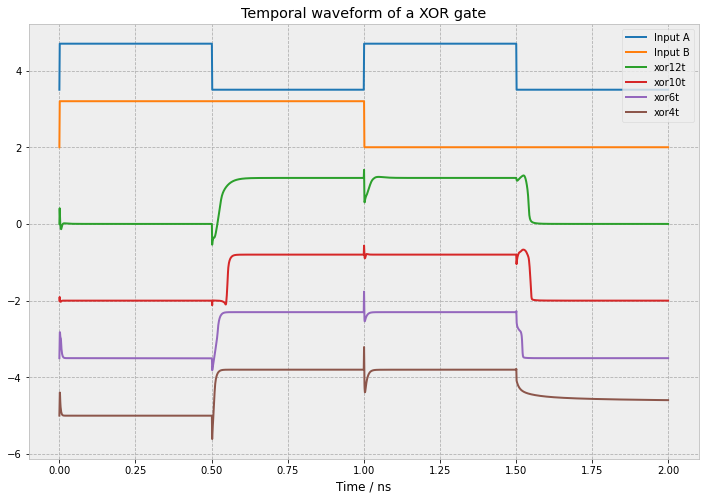

In [27]:
# Plot the transient waveforms
plt.figure(figsize=(12, 8))
plt.title("Temporal waveform of a XOR gate")

# Input signals (shifted vertically for clarity)
plt.plot(analysis.time * 1e8, np.array(analysis["va"]) + 3.5, label="Input A")
plt.plot(analysis.time * 1e8, np.array(analysis["vb"]) + 2.0, label="Input B")

# Output signal
plt.plot(analysis.time * 1e8, np.array(analysis["xor12t"]),     label="xor12t")
plt.plot(analysis.time * 1e8, np.array(analysis["xor10t"])-2.0, label="xor10t")
plt.plot(analysis.time * 1e8, np.array(analysis["xor6t"])-3.5, label="xor6t")
plt.plot(analysis.time * 1e8, np.array(analysis["xor4t"])-5.0,  label="xor4t")

# Axis labels and legend
plt.xlabel("Time / ns")
plt.legend()
plt.show()

It can be observed that the outputs differ depending on the circuit configurations. The only configuration that is truly different is the one using four transistors, which does not return to a low level. 

## System Response Time

The objective now is to study the response time of each system, specifically its rise time and fall time.

In [28]:
# ============================================================
# Compute the 95% threshold value
# ============================================================

# Convert signals to numpy arrays for clarity and efficiency
time = np.array(analysis.time)
va   = np.array(analysis["va"])

xor12t = np.array(analysis["xor12t"])
xor10t = np.array(analysis["xor10t"])
xor6t  = np.array(analysis["xor6t"])
xor4t  = np.array(analysis["xor4t"])

# Define the 95% threshold based on the maximum input amplitude
value_95 = np.max(va) * 0.95

In [29]:
# ============================================================
# Compute response times (time to reach 95% of final value)
# ============================================================

# For each configuration, find the first index where
# the output signal exceeds the 95% threshold

XOR12T_index = np.where(xor12t > value_95)[0][0]
XOR10T_index = np.where(xor10t > value_95)[0][0]
XOR6T_index  = np.where(xor6t  > value_95)[0][0]
XOR4T_index  = np.where(xor4t  > value_95)[0][0]

# Convert time to nanoseconds for readability
XOR12T_response = float(time[XOR12T_index] * 1e9)
XOR10T_response = float(time[XOR10T_index] * 1e9)
XOR6T_response  = float(time[XOR6T_index]  * 1e9)
XOR4T_response  = float(time[XOR4T_index]  * 1e9)

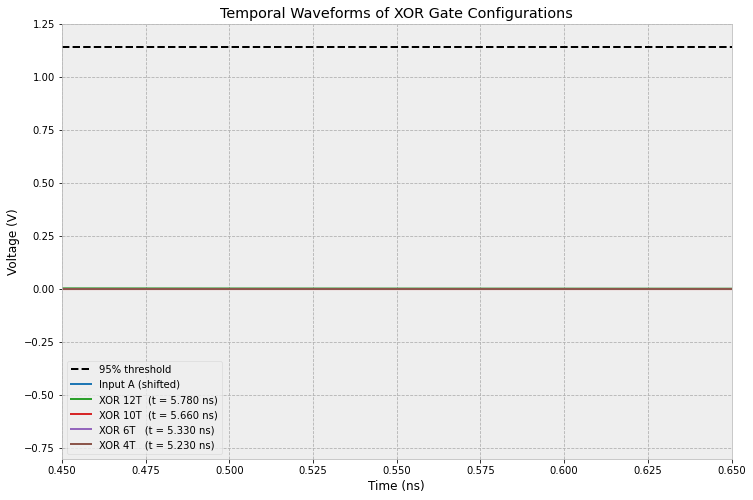

In [30]:
# ============================================================
# Plot transient waveforms
# ============================================================

plt.figure(figsize=(12, 8))
plt.title("Temporal Waveforms of XOR Gate Configurations")

# Plot 95% threshold line
plt.axhline(value_95, color="black", linestyle="--", label="95% threshold")

# Shift input signal vertically for better visualization
offset = np.max(va)
plt.plot(time * 1e9, -va + offset, label="Input A (shifted)", color="C0")

# Plot output signals with response time in legend
plt.plot(time * 1e9, xor12t, label=f"XOR 12T  (t = {XOR12T_response:.3f} ns)", color="C2")
plt.plot(time * 1e9, xor10t, label=f"XOR 10T  (t = {XOR10T_response:.3f} ns)", color="C3")
plt.plot(time * 1e9, xor6t,  label=f"XOR 6T   (t = {XOR6T_response:.3f} ns)",  color="C4")
plt.plot(time * 1e9, xor4t,  label=f"XOR 4T   (t = {XOR4T_response:.3f} ns)",  color="C5")

# Axis formatting
plt.xlabel("Time (ns)")
plt.ylabel("Voltage (V)")
plt.xlim(0.45, 0.65)
plt.ylim(-0.8, 1.25)

plt.legend()
plt.show()

It can be observed that the fewer transistors there are, the faster the response time to reach 95% of the final value.

For the 4T and 6T configurations, the behavior is perfectly linear: the response increases proportionally. However, the responses for the 10-transistor and 12-transistor configurations are different.

In the 10-transistor case, there is a relatively constant plateau lasting approximately 25 ps, followed by a relatively abrupt rise.

In contrast, for the 12-transistor case, the initial rise time in the first part of the graph is relatively short. However, the system then struggles to keep up and slows down significantly as it approaches 90% of the final value.


## Disciped energy

The goal of this part is to study the energy dissiped per the system

In [31]:
list_circuit = ["XOR12T", "XOR10T", "XOR6T", "XOR4T"]
list_sum     = dict()
list_mean    = dict()
list_time    = dict()

for subcircuit in list_circuit: 
    # Create the circuit object
    circuit = Circuit('Test energy')
    
    circuit.include('lib/ptm_65nm_nmos_bulk.mod')
    circuit.include('lib/ptm_65nm_pmos_bulk.mod')

    circuit.subcircuit(Inversor('INV'))
    circuit.subcircuit(TransmissionGate('TRANS'))
    circuit.subcircuit(Xor12T('XOR12T'))
    circuit.subcircuit(Xor10T('XOR10T'))
    circuit.subcircuit(Xor6T('XOR6T'))
    circuit.subcircuit(Xor4T('XOR4T'))
    
    # Supply voltage
    VDD = 1.2
    circuit.V('dd', 'vdd', circuit.gnd, VDD @ u_V)
    
    # Input A: faster pulse
    circuit.PulseVoltageSource(
        'A', 'va',circuit.gnd,
        0 @ u_V, VDD @ u_V,
        pulse_width=5 @ u_ns, period=10 @ u_ns
    )
    
    # Input B: slower pulse
    circuit.PulseVoltageSource(
        'B', 'vb', circuit.gnd,
        0 @ u_V, VDD @ u_V,
        pulse_width=10 @ u_ns, period=20 @ u_ns
    )
    
    circuit.X('X1', subcircuit, 'va', 'vb', 'vout', 'vdd')

    simulator = circuit.simulator(
        temperature=25,
        nominal_temperature=25
    )

    analysis = simulator.transient(
        step_time=0.1 @ u_ns,
        end_time=20 @ u_ns
    )

    P_va  = analysis.branches["va"]*analysis["va"]
    P_vb  = analysis.branches["vb"]*analysis["vb"]
    P_vdd = analysis.branches["vdd"]*analysis["vdd"]
    Somme = np.abs((P_va+P_vb+P_vdd))*1e6
    list_time[subcircuit] = np.float64(analysis.time)
    list_sum[subcircuit] = np.float64(Somme)
    list_mean[subcircuit] = np.sum(Somme) / len(Somme)

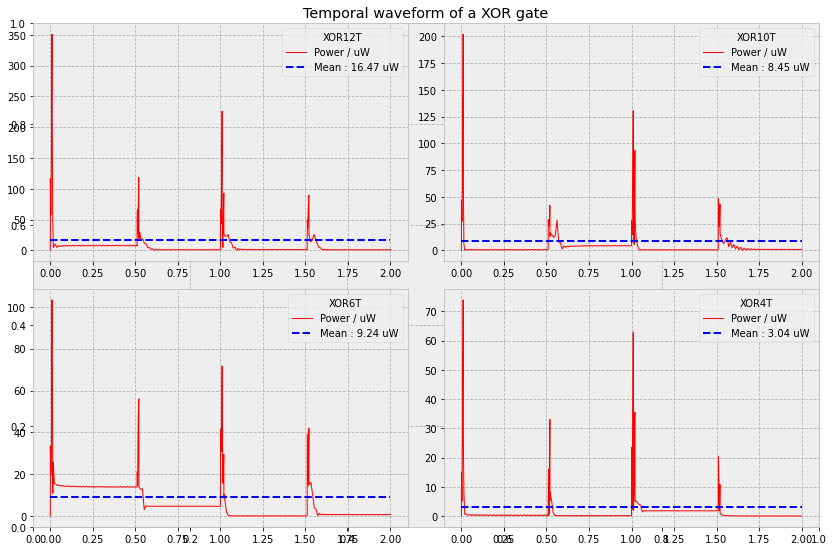

In [32]:
# Plot the transient waveforms
plt.figure(figsize=(12, 8))
plt.title("Temporal waveform of a XOR gate")

for i, j in enumerate(list_sum) :
    pos = 221 + i
    plt.subplot(pos)
    
    # Input signals (shifted vertically for clarity)
    plt.plot(list_time[j] * 1e8, list_sum[j], lw=1,
             label="Power / uW", c="red")
    plt.plot(list_time[j] * 1e8, np.ones(len(list_time[j]))*np.float64(list_mean[j]), 
             "--",
             label=f"Mean : {list_mean[j]:.2f} uW", c="blue")

    plt.legend(title=j)

plt.tight_layout()
plt.show()

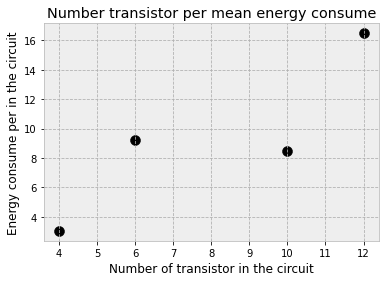

In [33]:
plt.figure()
for j in list_sum :
    
    num_transistor = int(j.split("XOR")[1].split("T")[0])
    mean_energy = np.float64(list_mean[j])

    plt.scatter(num_transistor, mean_energy, color="black", s=100)

plt.title("Number transistor per mean energy consume") 
plt.xlabel("Number of transistor in the circuit")
plt.ylabel("Energy consume per in the circuit")
plt.show()

Some circuits consume more power than others. For example, a circuit using 12 transistors has a power consumption of approximately $12 \ \mu\text{W}$, whereas when the number of transistors is reduced to 4, the consumption also decreases—in this case to about $3.04 \ \mu\text{W}$. From a rough estimation, it can be stated that a single transistor consumes approximately $1 \ \mu\text{W}$.

Another important aspect is identifying the type of system being studied and designing an appropriate state machine. For instance, in a circuit with 6 transistors, the power consumption when inputs A and B are in the high state is significantly higher than in a circuit with 10 transistors. However, the peak power levels are much lower in the 6-transistor configuration.

Therefore, the main objective is to understand under which operating conditions the system evolves, in order to determine the most suitable configuration and achieve the best possible trade-off between power consumption and performance.

There are many possible circuit implementations. Designing a logic function follows the same reasoning as algorithmic design: there is an infinite number of possible configurations. These configurations vary according to different parameters, such as the number of transistors, circuit compactness, noise robustness, rise and fall times, and many other factors.

## Reference

```{bibliography} ../../references.bib

```

* https://vlsiworlds.com/wp-content/uploads/2021/04/cmos-vlsi-design-by-weste.pdf

## Writing Matrix

| Author | Reviewer | Approver | Section | Date 1 | Date 2 | Date 3 | General Remarks |
|--------|----------|----------|---------|--------|--------|--------|------------------|
| Sacha  | /        | /        | Entire document | 2026-01-05 | / | / | Initial draft of the full document |